In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
from math import pi
import re
import json
from pathlib import Path


# Set style for better visualizations
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


In [2]:
def extract_logs(text):
    fwd_microstep, compute_norm, fwd, optimizer_allgather = [], [], [], []   
    for line in text:
        if "[Rank" in line:
            parts = line.split('|')[1:]
            metrics = {p.split(':')[0].strip(): float(p.split(':')[1].strip()) for p in parts if ':' in p}
            
            if 'fwd_microstep' in metrics:  
                # Add derived metrics
                metrics["real_compute_ms"] = (metrics["fwd_microstep"] + metrics["bwd_microstep"])
                metrics["real_comm_ms"] = metrics["bwd_allreduce_microstep"]
                metrics["real_comm_pct"] = (metrics["real_comm_ms"] / (metrics["real_comm_ms"] + metrics["real_compute_ms"] + 1e-8)) * 100
                metrics["total_microstep_time"] = (metrics["fwd_microstep"] + metrics["bwd_microstep"] + 
                                                   metrics.get("bwd_allreduce_microstep", 0) + 
                                                   metrics.get("step_microstep", 0))
                metrics["compute_efficiency"] = (metrics["real_compute_ms"] / metrics["total_microstep_time"]) * 100
                fwd_microstep.append(metrics) 
            elif 'compute_norm' in metrics:
                compute_norm.append(metrics)
            elif 'fwd' in metrics:
                fwd.append(metrics)
            elif ('optimizer_allgather' in metrics) or ('optimizer_step' in metrics):
                optimizer_allgather.append(metrics)
                
    return fwd_microstep, compute_norm, fwd, optimizer_allgather

csv_files = {
    0: "stage_0.csv",
    1: "stage_1.csv",
    2: "stage_2.csv",
    3: "stage_3.csv"
}

df_all = []

for stage_id, file in csv_files.items():
    df = pd.read_csv(file, index_col=0)
    df["stage"] = stage_id
    df_all.append(df)

df_all = pd.concat(df_all, ignore_index=True)

logs = ['stage_0_0-480.log',
        'stage_1_0-480.log',
        'stage_2_0-480.log',
        'stage_3_0-480.log']

micro_all = []
for stage_id in range(0, 4):
    with open(logs[stage_id]) as f:
        data = f.readlines()
        fwd_microstep, compute_norm, fwd, optimizer_allgather = extract_logs(data)
        df_fwd_microstep = pd.DataFrame(fwd_microstep)
        if not df_fwd_microstep.empty:
            df_fwd_microstep["stage"] = stage_id
            if 'microstep_idx' not in df_fwd_microstep.columns:
                df_fwd_microstep['microstep_idx'] = range(len(df_fwd_microstep))
            micro_all.append(df_fwd_microstep)

df_micro_all = pd.concat(micro_all, ignore_index=True)

# Print available columns
print("Microstep DataFrame columns:", df_micro_all.columns.tolist())

# Calculate communication percentage from microstep data only
micro_comm_summary = df_micro_all.groupby("stage").agg({
    "real_comm_pct": "mean"
}).reset_index()
micro_comm_summary.columns = ["stage", "comm_pct_from_microstep"]

print("\nMicrostep Communication Percentage Summary:")
print(micro_comm_summary)

Microstep DataFrame columns: ['fwd_microstep', 'bwd_microstep', 'bwd_inner_microstep', 'bwd_allreduce_microstep', 'step_microstep', 'real_compute_ms', 'real_comm_ms', 'real_comm_pct', 'total_microstep_time', 'compute_efficiency', 'stage', 'microstep_idx']

Microstep Communication Percentage Summary:
   stage  comm_pct_from_microstep
0      0                 6.025556
1      1                 5.998065
2      2                48.176957
3      3                37.253826


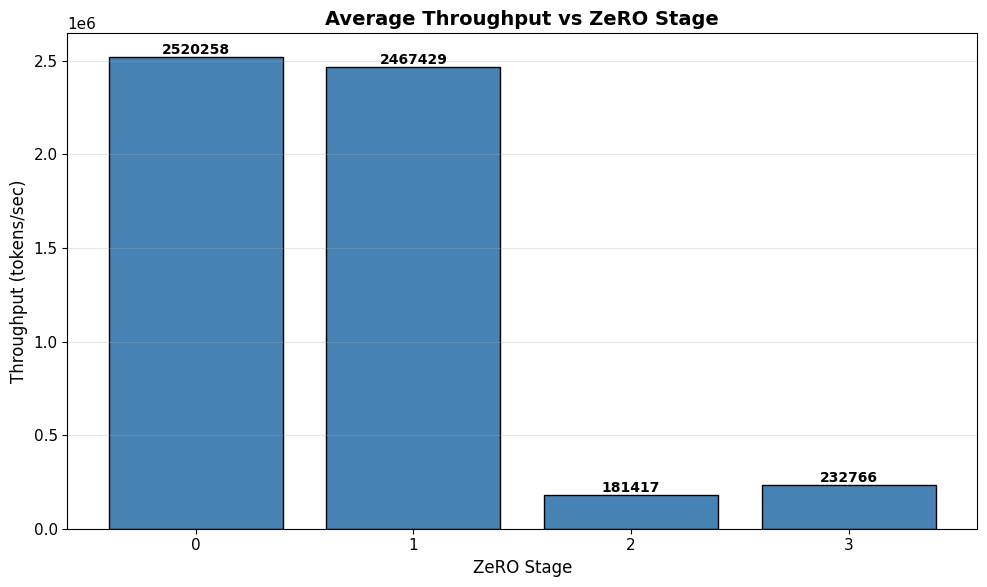

In [3]:
# ============================================================================
# 1. THROUGHPUT BAR CHART
# ============================================================================
plt.figure(figsize=(10, 6))
summary = df_all.groupby("stage").agg({
    "throughput_tps": "mean",
    "iteration_time_ms": "mean",
    "peak_gb": "mean",
    "alloc_gb": "mean",
    "gpu_util": "mean"
}).reset_index()

bars = plt.bar(summary["stage"], summary["throughput_tps"], color='steelblue', edgecolor='black')
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Throughput (tokens/sec)", fontsize=12)
plt.title("Average Throughput vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(summary["stage"])
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, summary["throughput_tps"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('01_throughput_bar.png', dpi=150, bbox_inches='tight')
plt.show()



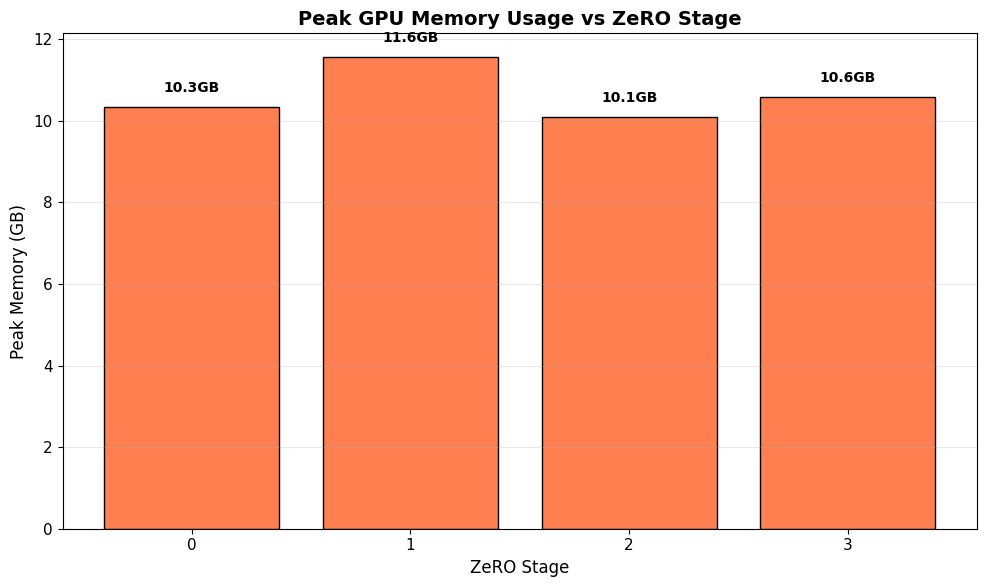

In [4]:
# ============================================================================
# 2. MEMORY BAR CHART
# ============================================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(summary["stage"], summary["peak_gb"], color='coral', edgecolor='black')
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Peak Memory (GB)", fontsize=12)
plt.title("Peak GPU Memory Usage vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(summary["stage"])
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, summary["peak_gb"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}GB', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('02_memory_bar.png', dpi=150, bbox_inches='tight')
plt.show()



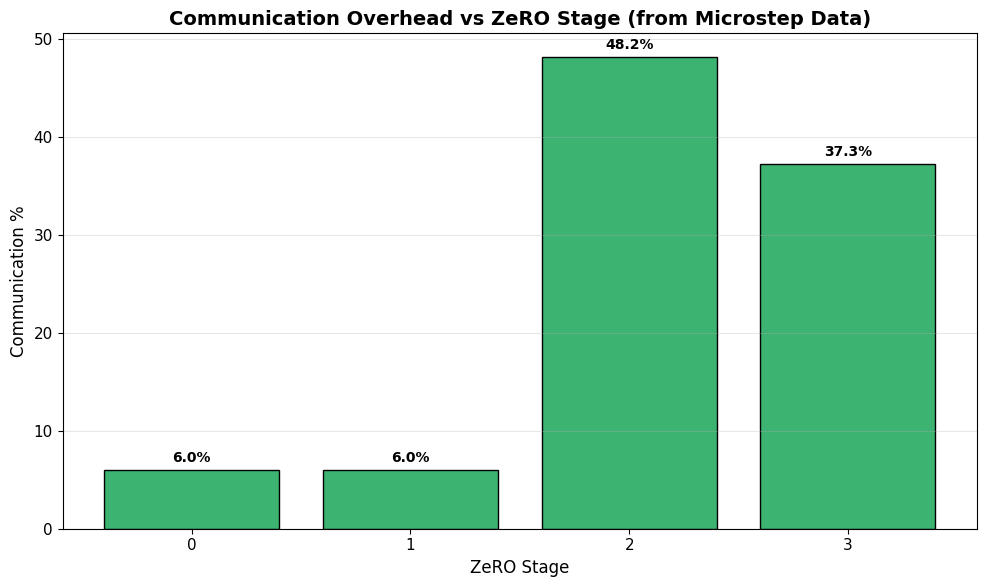

In [5]:
# ============================================================================
# 3. COMMUNICATION OVERHEAD BAR CHART (FROM MICROSTEP ONLY)
# ============================================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(micro_comm_summary["stage"], micro_comm_summary["comm_pct_from_microstep"], 
               color='mediumseagreen', edgecolor='black')
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Communication %", fontsize=12)
plt.title("Communication Overhead vs ZeRO Stage (from Microstep Data)", fontsize=14, fontweight='bold')
plt.xticks(micro_comm_summary["stage"])
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, micro_comm_summary["comm_pct_from_microstep"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('03_comm_overhead_bar.png', dpi=150, bbox_inches='tight')
plt.show()

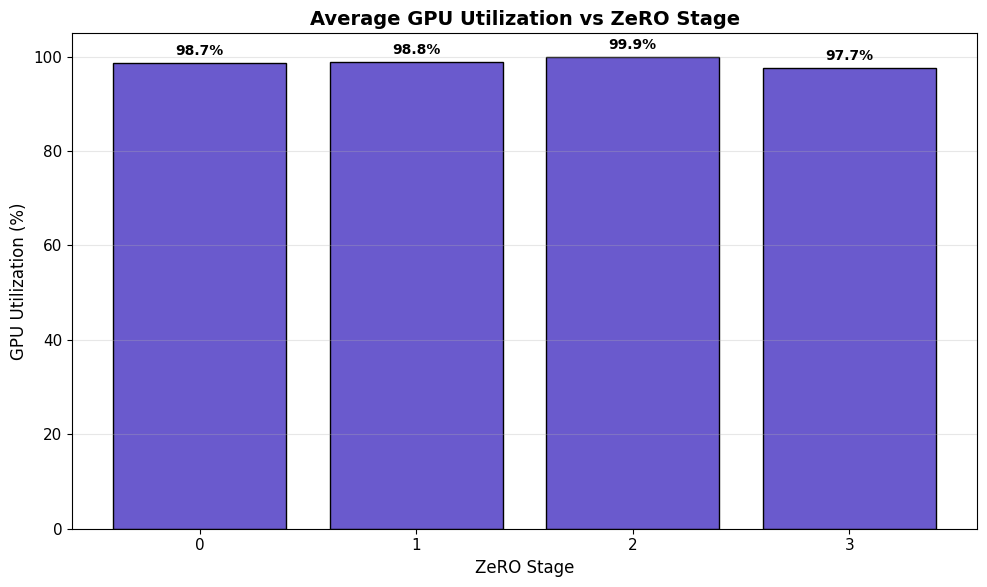

In [6]:
# ============================================================================
# 4. GPU UTILIZATION BAR CHART
# ============================================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(summary["stage"], summary["gpu_util"], color='slateblue', edgecolor='black')
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("GPU Utilization (%)", fontsize=12)
plt.title("Average GPU Utilization vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(summary["stage"])
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, summary["gpu_util"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('04_gpu_util_bar.png', dpi=150, bbox_inches='tight')
plt.show()



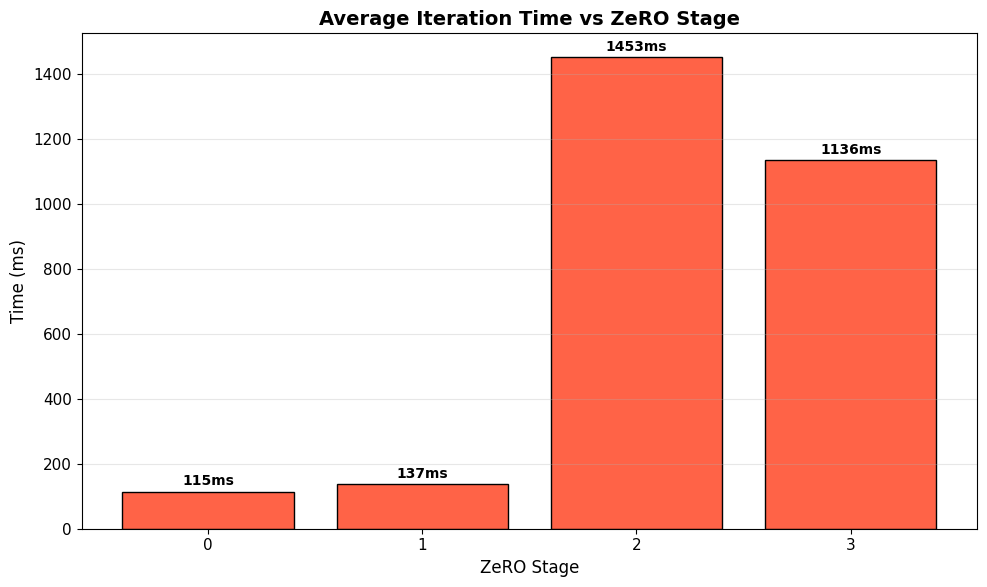

In [7]:
# ============================================================================
# 5. ITERATION TIME BAR CHART
# ============================================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(summary["stage"], summary["iteration_time_ms"], color='tomato', edgecolor='black')
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Time (ms)", fontsize=12)
plt.title("Average Iteration Time vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(summary["stage"])
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, summary["iteration_time_ms"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}ms', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('05_iteration_time_bar.png', dpi=150, bbox_inches='tight')
plt.show()



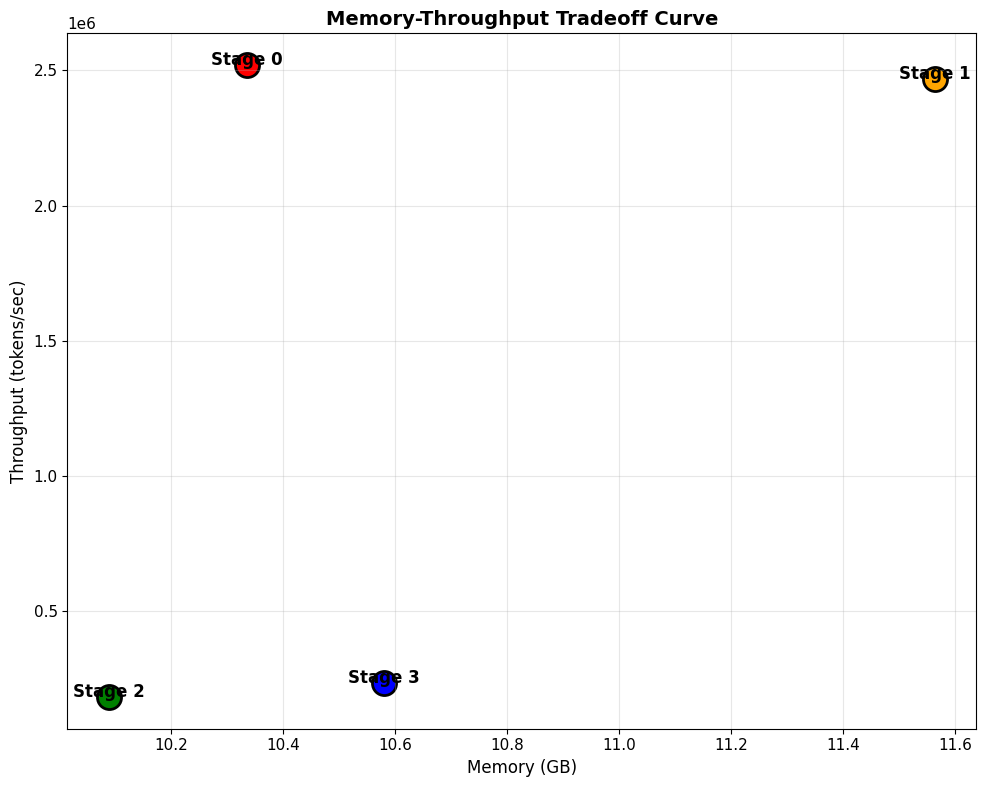

In [8]:
# ============================================================================
# 6. MEMORY VS THROUGHPUT TRADEOFF 
# ============================================================================
plt.figure(figsize=(10, 8))
colors = ['red', 'orange', 'green', 'blue']
for i, row in summary.iterrows():
    plt.scatter(row["peak_gb"], row["throughput_tps"], s=300, 
                c=[colors[i]], edgecolor='black', linewidth=2)
    plt.text(row["peak_gb"], row["throughput_tps"] + 15, f"Stage {int(row['stage'])}", 
             ha='center', fontweight='bold', fontsize=12)

plt.xlabel("Memory (GB)", fontsize=12)
plt.ylabel("Throughput (tokens/sec)", fontsize=12)
plt.title("Memory-Throughput Tradeoff Curve", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_memory_throughput_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()



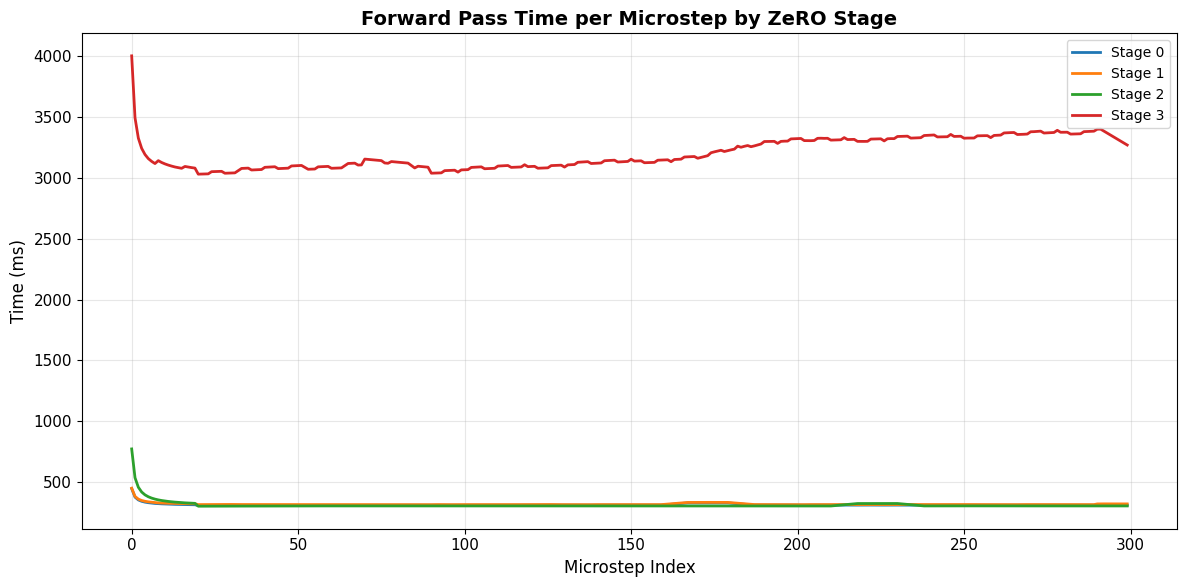

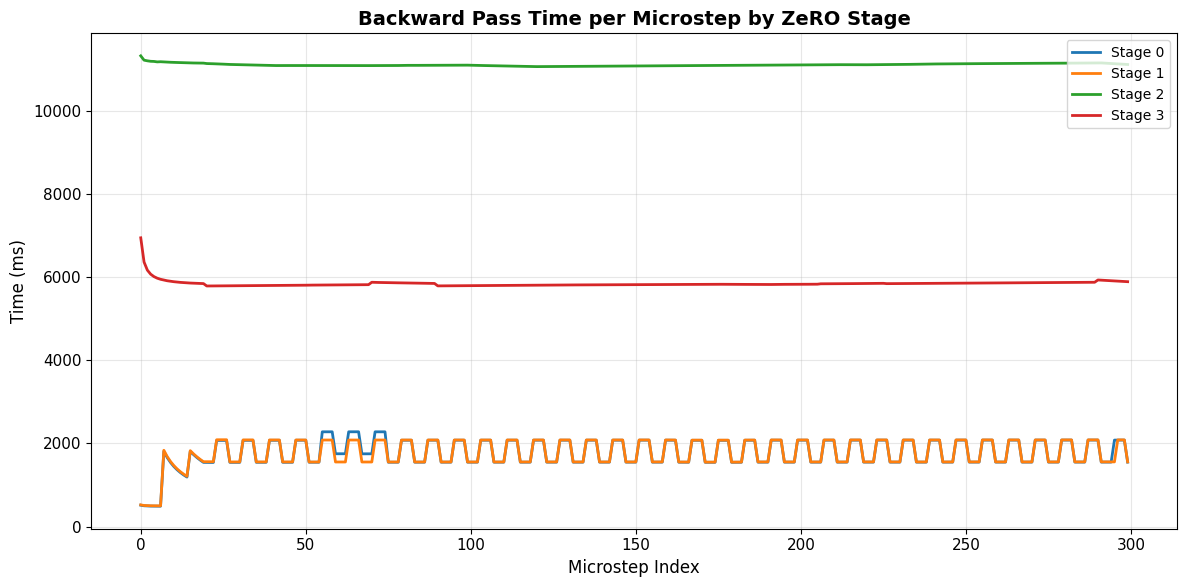

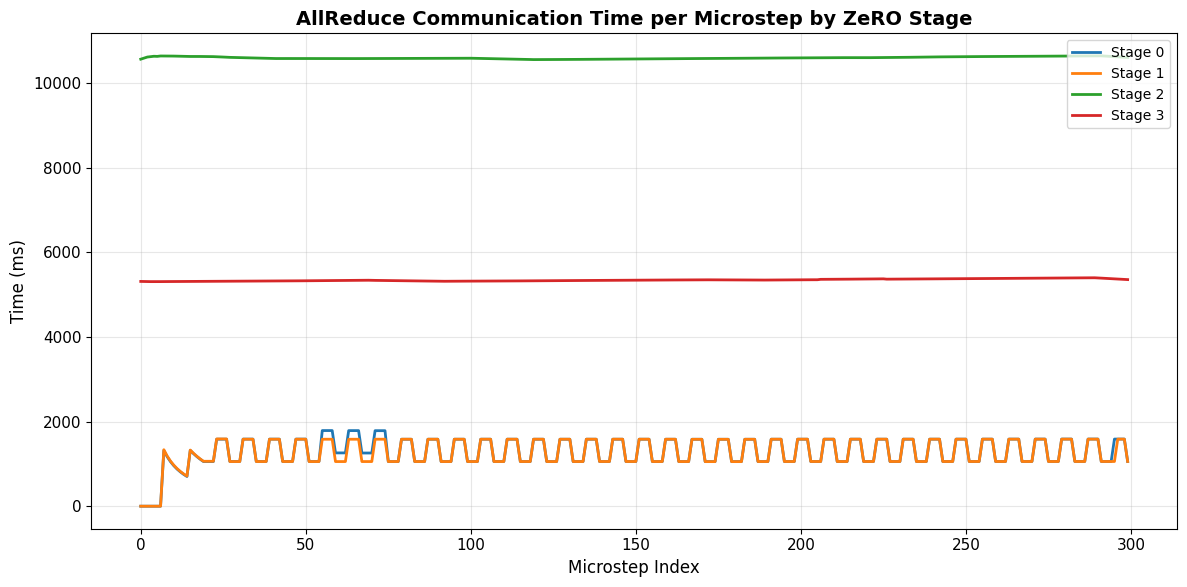

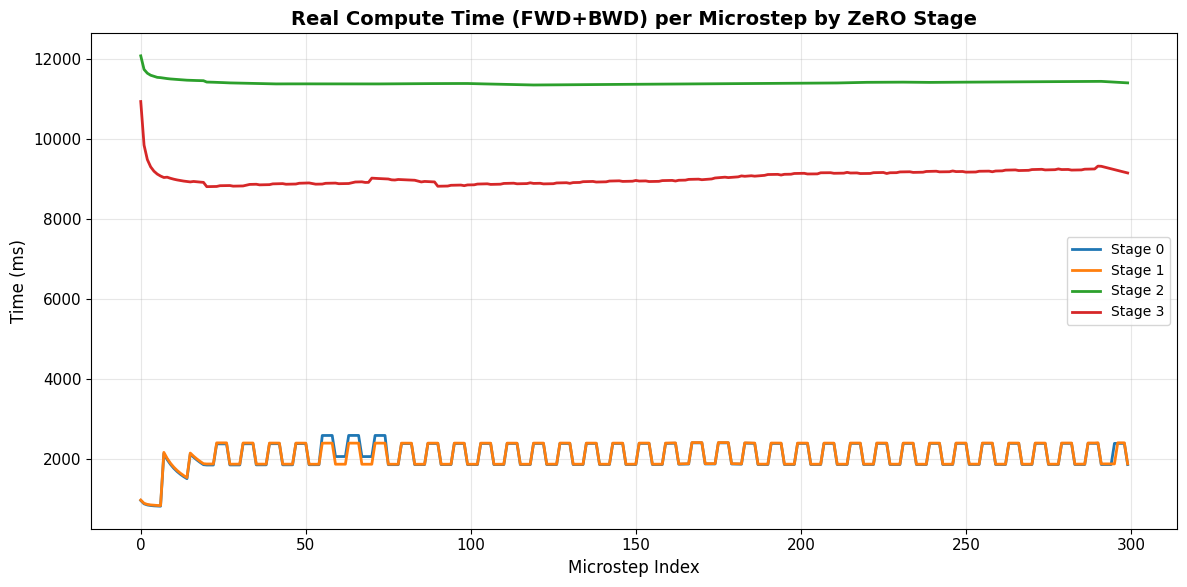

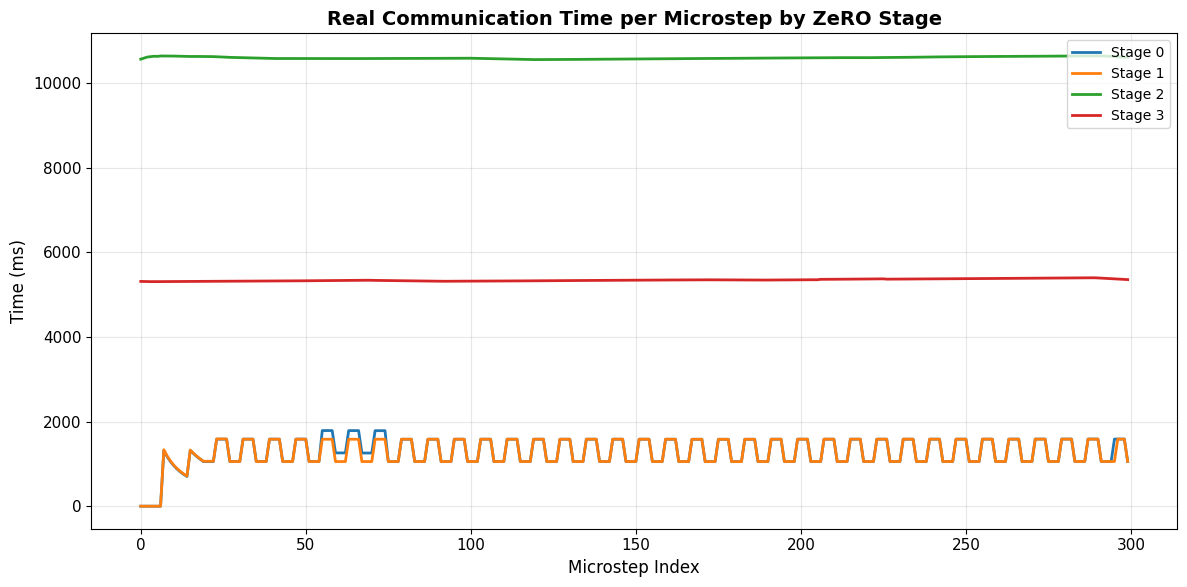

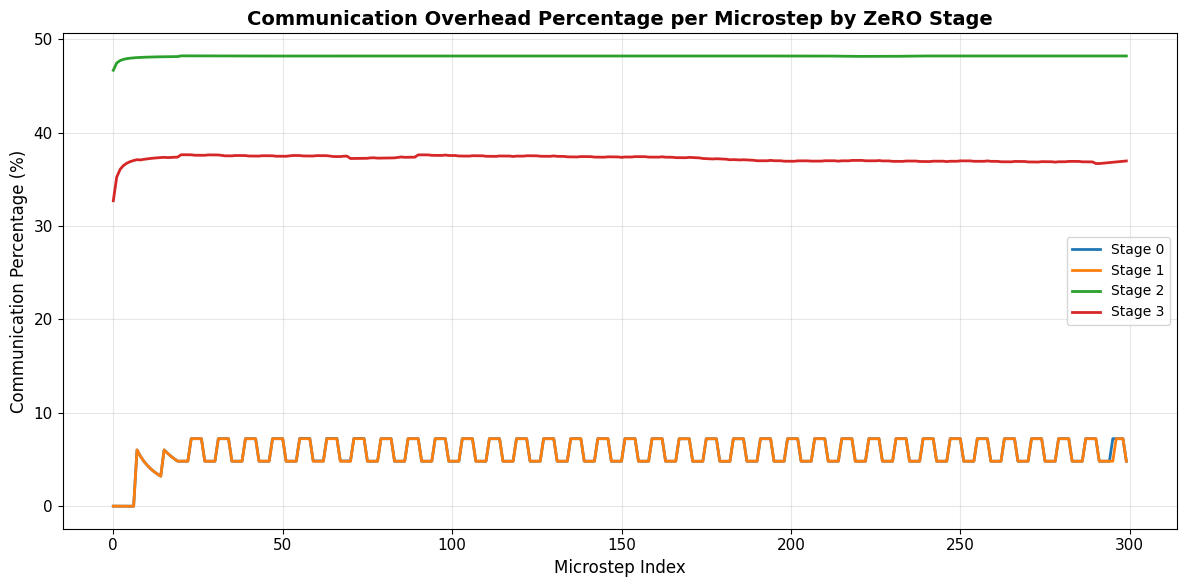

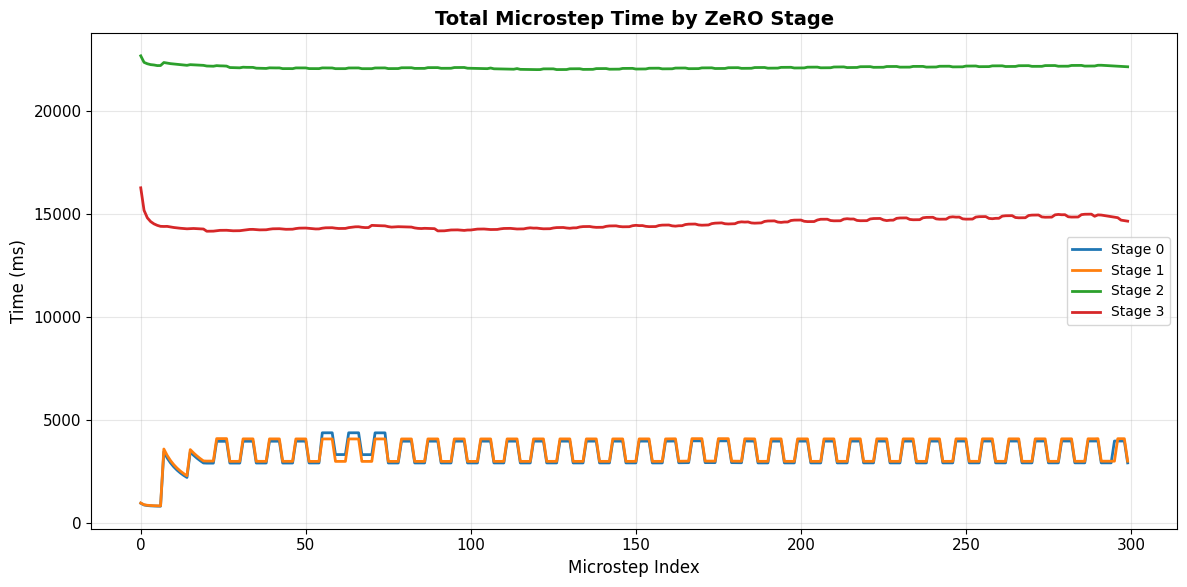

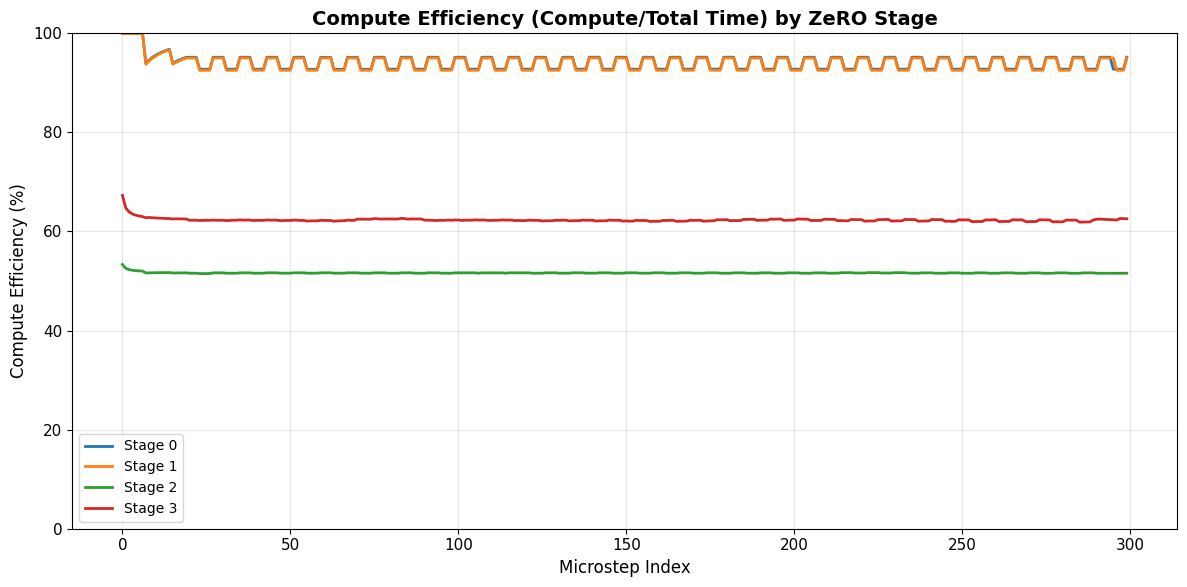

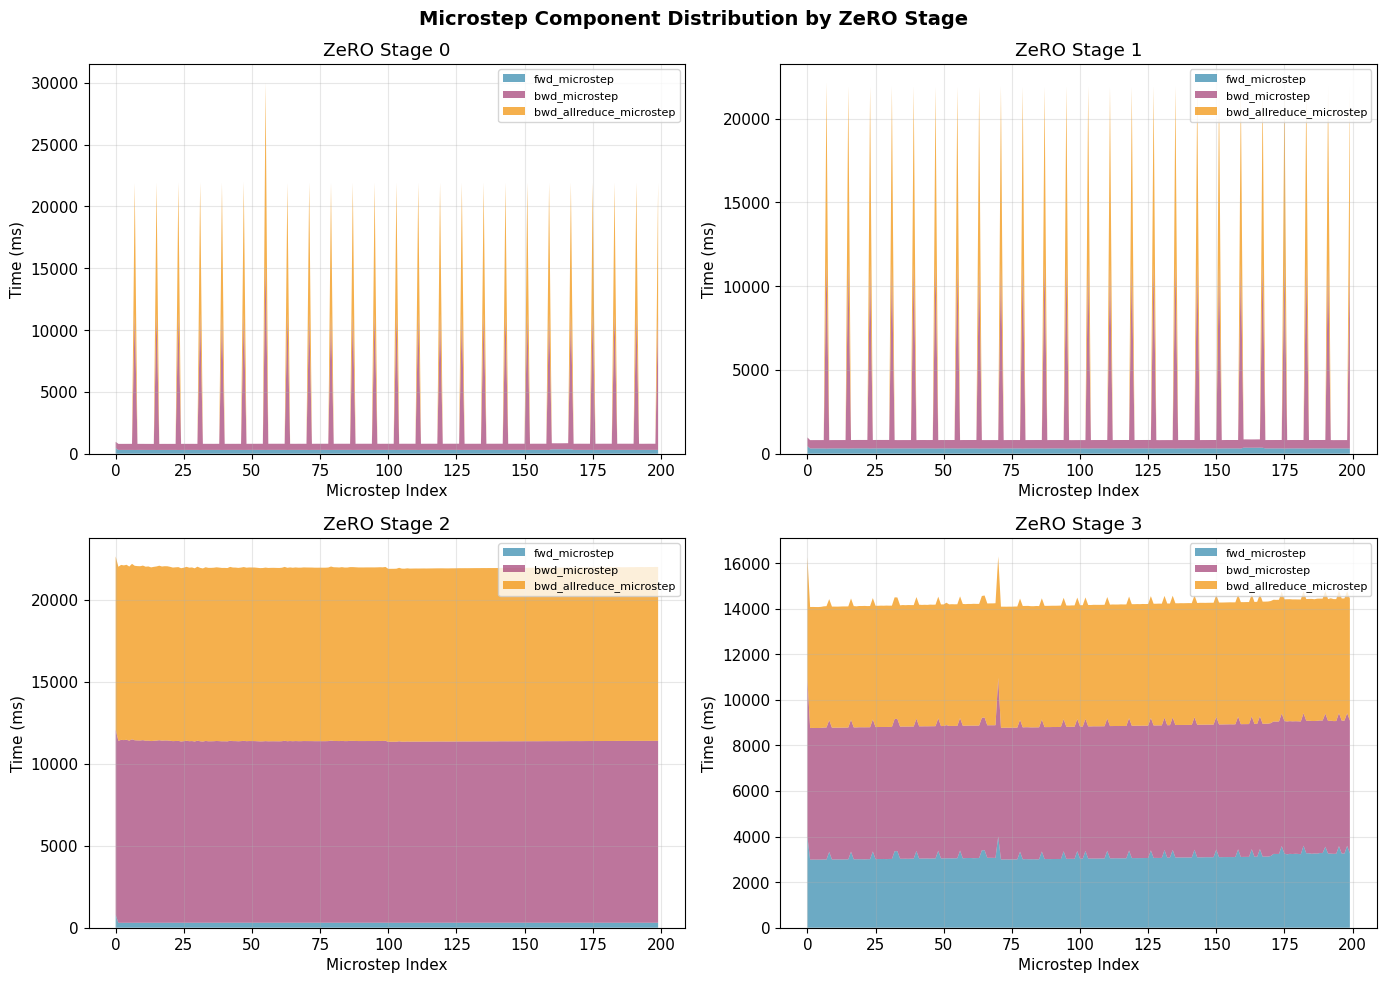

/tmp/ipykernel_645880/3742984750.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)
/tmp/ipykernel_645880/3742984750.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)
/tmp/ipykernel_645880/3742984750.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)


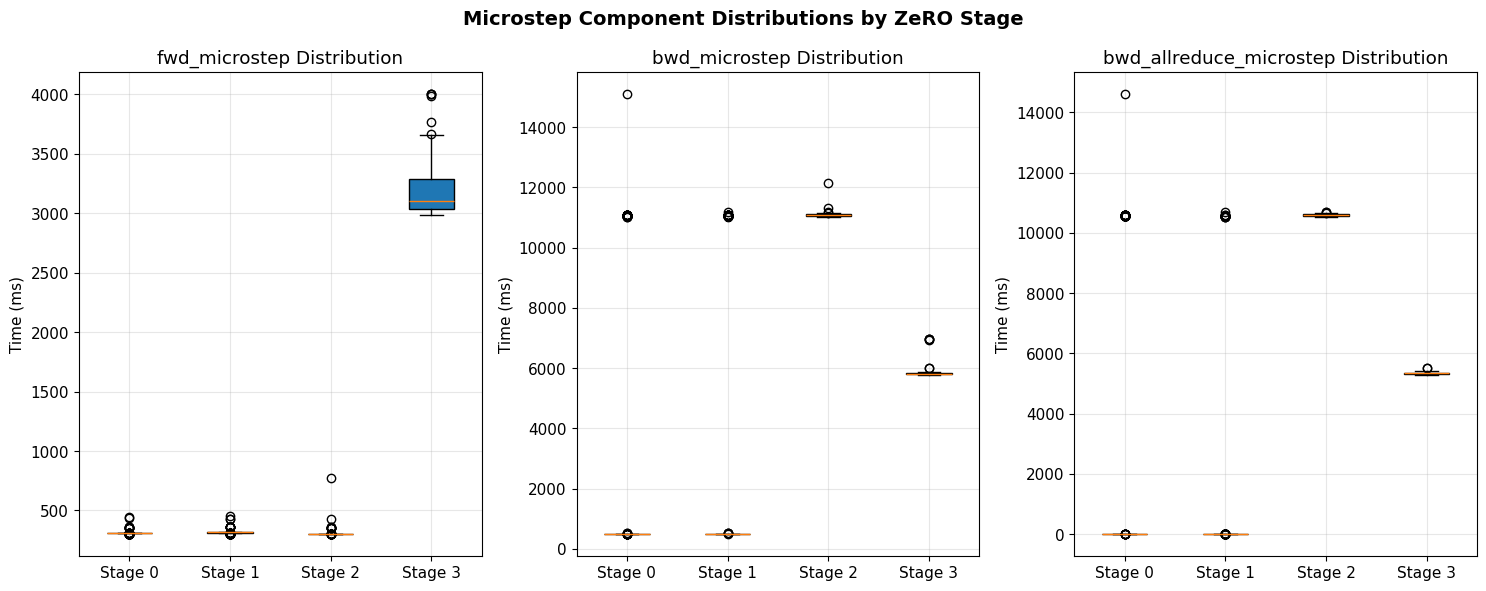

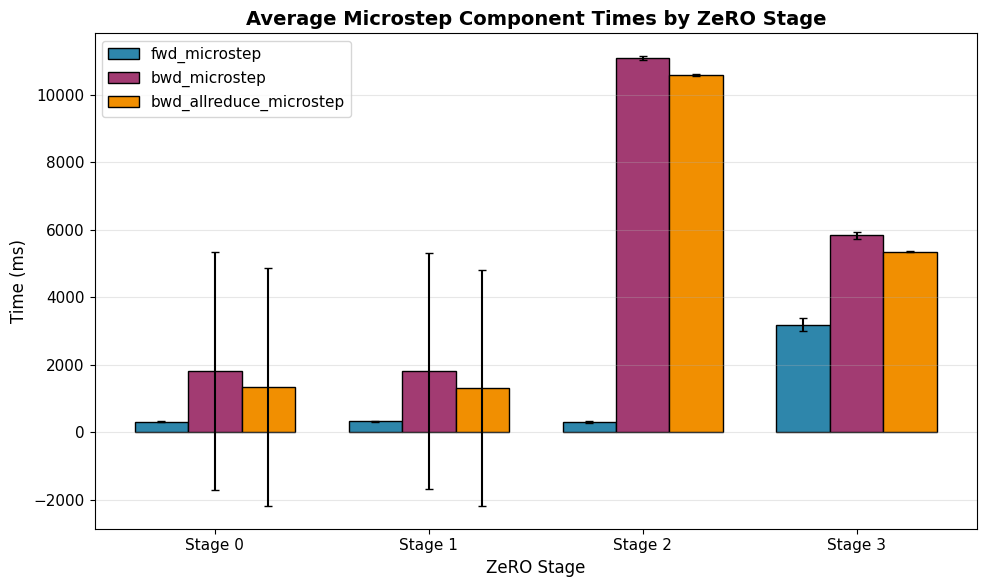

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

In [9]:
# ============================================================================
# 7. MICROSTEP BREAKDOWN - INDIVIDUAL PLOTS
# ============================================================================
if not df_micro_all.empty:
    micro_metrics = ['fwd_microstep', 'bwd_microstep', 'bwd_allreduce_microstep', 
                     'step_microstep', 'real_compute_ms', 'real_comm_ms', 
                     'real_comm_pct', 'total_microstep_time', 'compute_efficiency']
    
    available_micro_metrics = [m for m in micro_metrics if m in df_micro_all.columns]
    
    # Plot 7a: Forward Microstep Time by Stage
    if 'fwd_microstep' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['fwd_microstep'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Time (ms)", fontsize=12)
        plt.title("Forward Pass Time per Microstep by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07a_fwd_microstep.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7b: Backward Microstep Time by Stage
    if 'bwd_microstep' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['bwd_microstep'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Time (ms)", fontsize=12)
        plt.title("Backward Pass Time per Microstep by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07b_bwd_microstep.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7c: AllReduce Communication Time by Stage
    if 'bwd_allreduce_microstep' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['bwd_allreduce_microstep'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Time (ms)", fontsize=12)
        plt.title("AllReduce Communication Time per Microstep by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07c_allreduce_microstep.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7d: Real Compute Time by Stage
    if 'real_compute_ms' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['real_compute_ms'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Time (ms)", fontsize=12)
        plt.title("Real Compute Time (FWD+BWD) per Microstep by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07d_compute_time.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7e: Real Communication Time by Stage
    if 'real_comm_ms' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['real_comm_ms'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Time (ms)", fontsize=12)
        plt.title("Real Communication Time per Microstep by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07e_comm_time.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7f: Communication Percentage by Stage
    if 'real_comm_pct' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['real_comm_pct'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Communication Percentage (%)", fontsize=12)
        plt.title("Communication Overhead Percentage per Microstep by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07f_comm_percentage.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7g: Total Microstep Time by Stage
    if 'total_microstep_time' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['total_microstep_time'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Time (ms)", fontsize=12)
        plt.title("Total Microstep Time by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('07g_total_microstep.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # Plot 7h: Compute Efficiency by Stage
    if 'compute_efficiency' in df_micro_all.columns:
        plt.figure(figsize=(12, 6))
        for stage_id in df_micro_all["stage"].unique():
            sub = df_micro_all[df_micro_all["stage"] == stage_id].sort_values('microstep_idx')
            window = min(20, len(sub) // 10) if len(sub) > 20 else 1
            plt.plot(sub['microstep_idx'][:300], 
                    sub['compute_efficiency'].iloc[:300].rolling(window, min_periods=1).mean(), 
                    label=f'Stage {stage_id}', linewidth=2)
        plt.xlabel("Microstep Index", fontsize=12)
        plt.ylabel("Compute Efficiency (%)", fontsize=12)
        plt.title("Compute Efficiency (Compute/Total Time) by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.savefig('07h_compute_efficiency.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # ============================================================================
    # 7i. MICROSTEP COMPONENT STACKED AREA CHART
    # ============================================================================
    stack_components = ['fwd_microstep', 'bwd_microstep', 'bwd_allreduce_microstep']
    available = [c for c in stack_components if c in df_micro_all.columns]
    
    if len(available) >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Microstep Component Distribution by ZeRO Stage', fontsize=14, fontweight='bold')
        
        for idx, stage_id in enumerate(df_micro_all["stage"].unique()):
            ax = axes[idx // 2, idx % 2]
            sub = df_micro_all[df_micro_all["stage"] == stage_id].copy()
            sub = sub.sort_values('microstep_idx')
            
            # Create stacked area chart
            ax.stackplot(sub['microstep_idx'][:200],
                        [sub[c].iloc[:200] for c in available],
                        labels=available,
                        alpha=0.7,
                        colors=['#2E86AB', '#A23B72', '#F18F01'])
            
            ax.set_title(f"ZeRO Stage {stage_id}")
            ax.set_xlabel("Microstep Index")
            ax.set_ylabel("Time (ms)")
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('07i_stacked_area.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # ============================================================================
    # 7j. BOX PLOT OF MICROSTEP COMPONENTS BY STAGE
    # ============================================================================
    if len(available) >= 1:
        fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 6))
        if len(available) == 1:
            axes = [axes]
        
        for idx, metric in enumerate(available):
            data_to_plot = []
            labels = []
            for stage_id in df_micro_all["stage"].unique():
                sub = df_micro_all[df_micro_all["stage"] == stage_id]
                data_to_plot.append(sub[metric].dropna().values)
                labels.append(f"Stage {stage_id}")
            
            bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)
            axes[idx].set_title(f"{metric} Distribution")
            axes[idx].set_ylabel("Time (ms)")
            axes[idx].grid(True, alpha=0.3)
        
        plt.suptitle("Microstep Component Distributions by ZeRO Stage", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('07j_boxplot.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # ============================================================================
    # 7k. BAR CHART - AVERAGE MICROSTEP COMPONENTS BY STAGE
    # ============================================================================
    if len(available) >= 1:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x = np.arange(len(df_micro_all["stage"].unique()))
        width = 0.25
        colors = ['#2E86AB', '#A23B72', '#F18F01']
        
        for i, metric in enumerate(available):
            means = []
            stds = []
            for stage_id in df_micro_all["stage"].unique():
                sub = df_micro_all[df_micro_all["stage"] == stage_id]
                means.append(sub[metric].mean())
                stds.append(sub[metric].std())
            
            bars = ax.bar(x + i*width, means, width, label=metric, color=colors[i], 
                         yerr=stds, capsize=3, edgecolor='black')
        
        ax.set_xlabel("ZeRO Stage", fontsize=12)
        ax.set_ylabel("Time (ms)", fontsize=12)
        ax.set_title("Average Microstep Component Times by ZeRO Stage", fontsize=14, fontweight='bold')
        ax.set_xticks(x + width)
        ax.set_xticklabels([f"Stage {s}" for s in df_micro_all["stage"].unique()])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('07k_avg_components.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    # ============================================================================
    # 7l. HEATMAP OF MICROSTEP COMPONENT CORRELATIONS
    # ============================================================================
    if len(available) >= 2:
        plt.figure(figsize=(10, 8))
        corr_matrix = df_micro_all[available + ['stage']].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=1)
        plt.title("Correlation Between Microstep Components", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('07l_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()

In [ ]:
# ============================================================================
# 9. RADAR CHART (Using microstep comm percentage)
# ============================================================================
metrics_for_radar = ['throughput_tps', 'peak_gb', 'gpu_util', 'iteration_time_ms']
summary_norm = summary.copy()

# Add comm percentage from microstep
summary_norm = summary_norm.merge(micro_comm_summary, on="stage", how="left")

for metric in metrics_for_radar:
    if metric in ['throughput_tps', 'gpu_util']:
        summary_norm[f'{metric}_norm'] = (summary_norm[metric] - summary_norm[metric].min()) / (summary_norm[metric].max() - summary_norm[metric].min())
    else:
        summary_norm[f'{metric}_norm'] = 1 - (summary_norm[metric] - summary_norm[metric].min()) / (summary_norm[metric].max() - summary_norm[metric].min())

# Normalize comm percentage (lower is better)
if 'comm_pct_from_microstep' in summary_norm.columns:
    summary_norm['comm_pct_norm'] = 1 - (summary_norm['comm_pct_from_microstep'] - summary_norm['comm_pct_from_microstep'].min()) / (summary_norm['comm_pct_from_microstep'].max() - summary_norm['comm_pct_from_microstep'].min())

categories = ['Throughput', 'Memory Efficiency', 'Low Comm Overhead', 'GPU Utilization', 'Fast Iteration']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
for idx, stage in enumerate(summary_norm['stage']):
    values = [
        summary_norm.loc[idx, 'throughput_tps_norm'],
        summary_norm.loc[idx, 'peak_gb_norm'],
        summary_norm.loc[idx, 'comm_pct_norm'],
        summary_norm.loc[idx, 'gpu_util_norm'],
        summary_norm.loc[idx, 'iteration_time_ms_norm']
    ]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Stage {int(stage)}', color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_ylim(0, 1)
ax.set_title('ZeRO Stage Performance Radar Chart\n(Higher = Better)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig('10_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================================
# 10. SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("PERFORMANCE SUMMARY TABLE")
print("="*80)
print(summary.round(2).to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("COMMUNICATION PERCENTAGE (FROM MICROSTEP DATA)")
print("="*80)
print(micro_comm_summary.round(2).to_string(index=False))
print("="*80)

if not df_micro_all.empty:
    print("\n" + "="*80)
    print("MICROSTEP PERFORMANCE SUMMARY")
    print("="*80)
    micro_summary = df_micro_all.groupby("stage").agg({
        c: 'mean' for c in df_micro_all.select_dtypes(include=['float64', 'int64']).columns 
        if c not in ['stage', 'microstep_idx']
    }).reset_index()
    print(micro_summary.round(2).to_string(index=False))
    print("="*80)

print("\n" + "="*80)
print("TRADEOFF ANALYSIS")
print("="*80)

for _, row in summary.iterrows():
    stage = int(row['stage'])
    print(f"\nZeRO Stage {stage}:")
    print(f"  • Throughput: {row['throughput_tps']:.1f} tokens/sec")
    print(f"  • Memory: {row['peak_gb']:.1f} GB")
    # Get comm percentage from microstep
    comm_val = micro_comm_summary[micro_comm_summary['stage'] == stage]['comm_pct_from_microstep'].values[0]
    print(f"  • Communication Overhead (Microstep): {comm_val:.1f}%")
    print(f"  • GPU Utilization: {row['gpu_util']:.1f}%")
    print(f"  • Iteration Time: {row['iteration_time_ms']:.0f} ms")

if not df_micro_all.empty:
    print("\n" + "="*80)
    print("MICROSTEP INSIGHTS")
    print("="*80)
    for stage_id in df_micro_all["stage"].unique():
        sub = df_micro_all[df_micro_all["stage"] == stage_id]
        print(f"\nZeRO Stage {stage_id}:")
        if 'fwd_microstep' in sub.columns:
            print(f"  • Forward Time: {sub['fwd_microstep'].mean():.2f} ms")
        if 'bwd_microstep' in sub.columns:
            print(f"  • Backward Time: {sub['bwd_microstep'].mean():.2f} ms")
        if 'bwd_allreduce_microstep' in sub.columns:
            print(f"  • AllReduce Time: {sub['bwd_allreduce_microstep'].mean():.2f} ms")
        if 'real_comm_pct' in sub.columns:
            print(f"  • Communication %: {sub['real_comm_pct'].mean():.1f}%")
        if 'compute_efficiency' in sub.columns:
            print(f"  • Compute Efficiency: {sub['compute_efficiency'].mean():.1f}%")

baseline = summary[summary['stage'] == 0].iloc[0]
print("\n" + "="*80)
print("IMPROVEMENTS RELATIVE TO ZERO STAGE (Baseline)")
print("="*80)
for _, row in summary.iterrows():
    stage = int(row['stage'])
    if stage == 0:
        continue
    mem_reduction = (1 - row['peak_gb'] / baseline['peak_gb']) * 100
    throughput_change = (row['throughput_tps'] / baseline['throughput_tps'] - 1) * 100
    
    # Get comm change from microstep
    baseline_comm = micro_comm_summary[micro_comm_summary['stage'] == 0]['comm_pct_from_microstep'].values[0]
    current_comm = micro_comm_summary[micro_comm_summary['stage'] == stage]['comm_pct_from_microstep'].values[0]
    comm_increase = current_comm - baseline_comm
    
    print(f"\nStage {stage} vs Stage 0:")
    print(f"  • Memory Reduction: {mem_reduction:.1f}%")
    print(f"  • Communication Increase: +{comm_increase:.1f} percentage points")
    print(f"  • Throughput Change: {throughput_change:+.1f}%")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

best_throughput = summary.loc[summary['throughput_tps'].idxmax(), 'stage']
best_memory = summary.loc[summary['peak_gb'].idxmin(), 'stage']
best_balance_idx = ((summary['throughput_tps'] / summary['throughput_tps'].max()) - 
                    (summary['peak_gb'] / summary['peak_gb'].max())).idxmax()
best_balance = summary.loc[best_balance_idx, 'stage']

print(f"\n• Best for Throughput: ZeRO Stage {int(best_throughput)}")
print(f"• Best for Memory: ZeRO Stage {int(best_memory)}")
print(f"• Best Tradeoff (Memory+Throughput): ZeRO Stage {int(best_balance)}")
print("\n• Recommendation: Choose based on your constraints:")
print("  - Memory-bound training → Higher ZeRO stages (2-3)")
print("  - Compute-bound training → Lower ZeRO stages (0-1)")
print("  - Balanced workload → ZeRO Stage 2 often provides optimal tradeoff")

In [ ]:
# ============================================================================
# LOAD PERPLEXITY RESULTS FROM ALL STAGES
# ============================================================================

def load_perplexity_results(stage_paths):
    """
    Load perplexity results from JSON files for different ZeRO stages.
    
    Args:
        stage_paths: dict {stage_id: file_path}
    
    Returns:
        DataFrame with columns: stage, step, perplexity
    """
    all_data = []
    
    for stage_id, file_path in stage_paths.items():
        if Path(file_path).exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            for item in data:
                # Extract step number from checkpoint name (e.g., "global_step128")
                step = int(item['checkpoint'].split('_')[-1].replace("step",''))
                
                all_data.append({
                    'stage': stage_id,
                    'step': step,
                    'perplexity': item['perplexity'],
                    'checkpoint': item['checkpoint']
                })
            
            print(f"✓ Loaded {len(data)} perplexity entries for Stage {stage_id}")
        else:
            print(f"✗ File not found: {file_path}")
    
    df = pd.DataFrame(all_data)
    return df

# Define file paths
perplexity_files = {
    0: "../outputs/stage_0/perplexity_results.json",
    1: "../outputs/stage_1/perplexity_results.json",
    2: "../outputs/stage_2/perplexity_results.json",
    3: "../outputs/stage_3/perplexity_results.json"
}

# Load data
df_perplexity = load_perplexity_results(perplexity_files)

print(f"\nTotal loaded: {len(df_perplexity)} entries")
print(df_perplexity.head())

# ============================================================================
# PLOT 1: PERPLEXITY OVER TRAINING STEPS (LINE PLOT)
# ============================================================================
plt.figure(figsize=(12, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
markers = ['o', 's', '^', 'D']

for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    plt.plot(stage_data['step'], stage_data['perplexity'], 
             marker=markers[idx], markersize=8, linewidth=2,
             label=f'ZeRO Stage {stage}', color=colors[idx], markevery=5)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Perplexity', fontsize=12)
plt.title('Perplexity vs Training Steps Across ZeRO Stages', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Perplexity typically improves exponentially, log scale helps visualization

# Add annotations for best perplexity at final step
for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        final_step = stage_data['step'].iloc[-1]
        final_ppl = stage_data['perplexity'].iloc[-1]
        plt.annotate(f'{final_ppl:.0f}', 
                    xy=(final_step, final_ppl),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx], alpha=0.3))

plt.tight_layout()
plt.savefig('perplexity_over_steps.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 2: PERPLEXITY BAR CHART (FINAL CHECKPOINT COMPARISON)
# ============================================================================
plt.figure(figsize=(10, 6))

# Get final perplexity for each stage
final_ppl = []
stages = []
for stage in sorted(df_perplexity['stage'].unique()):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        final_ppl.append(stage_data['perplexity'].iloc[-1])
        stages.append(stage)

bars = plt.bar([f'Stage {s}' for s in stages], final_ppl, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(stages)],
               edgecolor='black', linewidth=1.5)

plt.xlabel('ZeRO Stage', fontsize=12)
plt.ylabel('Final Perplexity', fontsize=12)
plt.title('Final Perplexity Comparison Across ZeRO Stages', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, final_ppl):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('final_perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 3: PERPLEXITY IMPROVEMENT RELATIVE TO STAGE 0
# ============================================================================
plt.figure(figsize=(10, 6))

# Get baseline (Stage 0 final perplexity)
stage0_data = df_perplexity[df_perplexity['stage'] == 0].sort_values('step')
if not stage0_data.empty:
    baseline_ppl = stage0_data['perplexity'].iloc[-1]
    
    improvements = []
    stages = []
    for stage in sorted(df_perplexity['stage'].unique()):
        stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
        if not stage_data.empty:
            final_ppl = stage_data['perplexity'].iloc[-1]
            improvement = (baseline_ppl - final_ppl) / baseline_ppl * 100
            improvements.append(improvement)
            stages.append(stage)
    
    colors_bar = ['red' if imp < 0 else 'green' for imp in improvements]
    bars = plt.bar([f'Stage {s}' for s in stages], improvements, 
                   color=colors_bar, edgecolor='black', linewidth=1.5)
    
    plt.xlabel('ZeRO Stage', fontsize=12)
    plt.ylabel('Improvement (%)', fontsize=12)
    plt.title(f'Perplexity Improvement Relative to Stage 0 (Baseline: {baseline_ppl:.0f})', 
              fontsize=14, fontweight='bold')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, imp in zip(bars, improvements):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if imp >= 0 else -15), 
                 f'{imp:+.1f}%', ha='center', va='bottom' if imp >= 0 else 'top', 
                 fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('perplexity_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# PLOT 4: SUBPLOT GRID WITH ALL STAGES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perplexity Evolution by ZeRO Stage', fontsize=16, fontweight='bold')

for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    ax = axes[idx // 2, idx % 2]
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    
    ax.plot(stage_data['step'], stage_data['perplexity'], 
            marker='o', markersize=6, linewidth=2, color='steelblue', markevery=3)
    ax.set_xlabel('Training Steps', fontsize=10)
    ax.set_ylabel('Perplexity', fontsize=10)
    ax.set_title(f'ZeRO Stage {stage}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Add annotations for key points
    first_ppl = stage_data['perplexity'].iloc[0]
    final_ppl = stage_data['perplexity'].iloc[-1]
    reduction = (first_ppl - final_ppl) / first_ppl * 100
    
    ax.text(0.05, 0.95, f'Start: {first_ppl:.0f}\nFinal: {final_ppl:.0f}\nReduction: {reduction:.1f}%',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.savefig('perplexity_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 5: PERPLEXITY vs GPU MEMORY (Tradeoff Analysis)
# ============================================================================
# Merge with memory data from your training metrics
# If you have memory data from training, you can create this plot

# Example: Assuming you have a summary DataFrame with memory usage
# If not, you can skip this plot or add dummy data

try:
    # If you have df_all from previous analysis
    if 'df_all' in globals():
        memory_by_stage = df_all.groupby('stage')['peak_gb'].mean().reset_index()
        perplexity_by_stage = df_perplexity.groupby('stage').agg({
            'perplexity': 'last'
        }).reset_index()
        
        merged = pd.merge(memory_by_stage, perplexity_by_stage, on='stage')
        
        plt.figure(figsize=(10, 8))
        for _, row in merged.iterrows():
            plt.scatter(row['peak_gb'], row['perplexity'], s=300, 
                       c=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][int(row['stage'])],
                       edgecolor='black', linewidth=2)
            plt.text(row['peak_gb'], row['perplexity'] + 200, f"Stage {int(row['stage'])}", 
                    ha='center', fontweight='bold', fontsize=11)
        
        plt.xlabel('Peak Memory (GB)', fontsize=12)
        plt.ylabel('Final Perplexity', fontsize=12)
        plt.title('Memory-Perplexity Tradeoff', fontsize=14, fontweight='bold')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        
        # Add arrow to show tradeoff direction
        plt.annotate('Better →', xy=(merged['peak_gb'].min(), merged['perplexity'].min()), 
                    xytext=(0.05, 0.95), textcoords='axes fraction',
                    fontsize=10, fontweight='bold', color='green')
        
        plt.tight_layout()
        plt.savefig('memory_perplexity_tradeoff.png', dpi=150, bbox_inches='tight')
        plt.show()
except NameError:
    print("Skipping memory-perplexity tradeoff plot (df_all not available)")

# ============================================================================
# PRINT SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("PERPLEXITY RESULTS SUMMARY")
print("="*80)

summary_data = []
for stage in sorted(df_perplexity['stage'].unique()):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        first_ppl = stage_data['perplexity'].iloc[0]
        final_ppl = stage_data['perplexity'].iloc[-1]
        improvement = (first_ppl - final_ppl) / first_ppl * 100
        
        summary_data.append({
            'Stage': stage,
            'Initial Perplexity': f'{first_ppl:.0f}',
            'Final Perplexity': f'{final_ppl:.0f}',
            'Improvement': f'{improvement:.1f}%',
            'Checkpoints': len(stage_data)
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================================================
# BEST PERFORMING STAGE
# ============================================================================
print("\n" + "="*80)
print("BEST PERFORMING CONFIGURATION")
print("="*80)

best_stage_row = summary_df.loc[summary_df['Final Perplexity'].astype(float).idxmin()]
print(f"\nBest Final Perplexity: ZeRO Stage {best_stage_row['Stage'].values[0] if hasattr(best_stage_row['Stage'], 'values') else best_stage_row['Stage']}")
print(f"  Final Perplexity: {best_stage_row['Final Perplexity']}")
print(f"  Improvement from start: {best_stage_row['Improvement']}")

# Calculate which stage improved most
best_improvement_row = summary_df.loc[summary_df['Improvement'].str.rstrip('%').astype(float).idxmax()]
print(f"\nBest Improvement Rate: ZeRO Stage {best_improvement_row['Stage'].values[0] if hasattr(best_improvement_row['Stage'], 'values') else best_improvement_row['Stage']}")
print(f"  Improvement: {best_improvement_row['Improvement']}")
print(f"  Final Perplexity: {best_improvement_row['Final Perplexity']}")


In [ ]:
def analyze_response_quality(df_perplexity, stage=0):
    """
    Optional function to analyze sample response quality from checkpoints
    """
    import json
    
    file_path = perplexity_files.get(stage)
    if file_path and Path(file_path).exists():
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        print(f"\n" + "="*80)
        print(f"SAMPLE RESPONSES - ZeRO Stage {stage}")
        print("="*80)
        
        for item in data[:3]:  # Show first 3 checkpoints
            print(f"\nCheckpoint: {item['checkpoint']}")
            print(f"Perplexity: {item['perplexity']:.0f}")
            print(f"Prompt: {item['sample']['prompt']}")
            print(f"Response: {item['sample']['response'][:150]}...")
            print("-" * 40)

# Sample responses
for stage in [0, 1, 2, 3]:
    analyze_response_quality(df_perplexity, stage)

In [ ]:
import pandas as pd

data = [
    ["0-480", 0, 125829120, 1136.74, 456.28, 1593.02],
    ["0-480", 1, 125829120, 1200.71, 439.22, 1639.93],
    ["0-480", 2, 125829120, 2762.33, 435.02, 3197.35],
    ["0-480", 3, 125829120, 2226.325, 460.75, 2687.075],
]

columns = [
    "steps",
    "stage",
    "token_processed",
    "train_time",
    "inference_time",
    "total_time"
]

df = pd.DataFrame(data, columns=columns)
df["throughput_tokens_per_sec"] = df["token_processed"] / df["train_time"]
df